In [ ]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [ ]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
images, attrs = fetch_dataset()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_photos, test_photos, train_attr, test_attr = train_test_split(images, attrs, train_size=0.85, shuffle = False)

array([[[ 92,  66,  38],
        [ 97,  67,  39],
        [132,  96,  68],
        ...,
        [ 88,  58,  39],
        [ 79,  58,  42],
        [ 75,  59,  45]],

       [[ 99,  71,  42],
        [115,  84,  55],
        [160, 122,  94],
        ...,
        [ 89,  59,  40],
        [ 80,  58,  41],
        [ 73,  57,  42]],

       [[107,  77,  47],
        [132,  99,  70],
        [175, 135, 106],
        ...,
        [ 90,  59,  40],
        [ 78,  56,  39],
        [ 67,  51,  36]],

       ...,

       [[162, 164, 188],
        [175, 170, 187],
        [151, 135, 142],
        ...,
        [ 64,  61,  55],
        [ 62,  63,  57],
        [ 63,  65,  61]],

       [[164, 167, 189],
        [173, 169, 186],
        [143, 128, 137],
        ...,
        [ 65,  61,  57],
        [ 65,  66,  61],
        [ 63,  65,  62]],

       [[164, 167, 189],
        [170, 167, 184],
        [139, 127, 137],
        ...,
        [ 69,  66,  62],
        [ 69,  69,  66],
        [ 65,  67,  66]]], dtype=uint8)
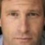

In [ ]:
train_photos[0]


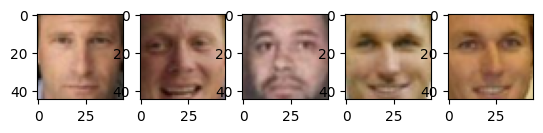

In [ ]:
for i in range(5):
  plt.subplot(1, 5, i+1, )
  plt.imshow(train_photos[i])

In [ ]:
train_photos = torch.FloatTensor(train_photos)
test_photos = torch.FloatTensor(test_photos)

In [ ]:
dim_code = 128

In [ ]:
from torch.nn.modules.flatten import Flatten
from torch.nn.modules.batchnorm import BatchNorm2d
from torch.nn.modules.activation import ReLU
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 5, kernel_size = 2, stride = 1),
            nn.ReLU(),
            nn.BatchNorm2d(num_features = 5),
            nn.Conv2d(in_channels = 5, out_channels = 3, kernel_size = 2, stride = 1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 3, kernel_size = 1, stride = 1),
            nn.ReLU(),
            nn.BatchNorm2d(num_features = 3),
            nn.ConvTranspose2d(in_channels = 3, out_channels = 5, kernel_size=2, stride = 1),
            nn.ReLU(),
            nn.BatchNorm2d(num_features = 5),
            nn.ConvTranspose2d(in_channels = 5, out_channels = 3, kernel_size = 2, stride = 1),

        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code
    def sample(self, z):
        generated = self.decoder(z)
        return generated




In [ ]:
criterion = F.mse_loss

autoencoder = Autoencoder()

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_photos, batch_size = 32)
test_loader = torch.utils.data.DataLoader(test_photos, batch_size = 32)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
/content

NameError: name 'content' is not defined

In [ ]:
%cd /content
!ls

/content
sample_data


In [ ]:
%cd /.

/


In [ ]:
from tqdm import tqdm_notebook
import tqdm
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = autoencoder.to(device)
num_epoch = 30
train_loss = []
test_loss = []
for epoch in tqdm.notebook.tqdm(range(num_epoch)):
  model.train()
  train_loss_in_epoch = []
  for X_batch, y_batch in train_loader:
    X_batch = X_batch.contiguous().to(device)
    reconstructed, latent = model(X_batch)
    loss = criterion(reconstructed, X_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss_in_epoch.append(loss.item())
  train_loss.append(np.mean(train_loss_in_epoch))

In [ ]:
train_loss

[np.float64(18004.28328125),
 np.float64(14654.064909319197),
 np.float64(10514.322809709822),
 np.float64(6504.1328920200895),
 np.float64(3398.701193847656),
 np.float64(1623.7511333356586),
 np.float64(854.5588794817244),
 np.float64(569.8653760637555),
 np.float64(462.4900213623047),
 np.float64(414.15539899553573),
 np.float64(385.59570966448103),
 np.float64(366.04421870640346),
 np.float64(351.4763448224749),
 np.float64(339.7857281930106),
 np.float64(333.4210223824637),
 np.float64(322.27511914934433),
 np.float64(315.86016379220143),
 np.float64(309.41677730015346),
 np.float64(303.6437542288644),
 np.float64(299.31906463623045),
 np.float64(295.40009447370255),
 np.float64(291.6532817731585),
 np.float64(290.71156633649554),
 np.float64(284.99364785330636),
 np.float64(280.4519566999163),
 np.float64(276.82502694266185),
 np.float64(273.7071023123605),
 np.float64(271.00683942522323),
 np.float64(268.8501346261161),
 np.float64(266.9583158656529)]

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

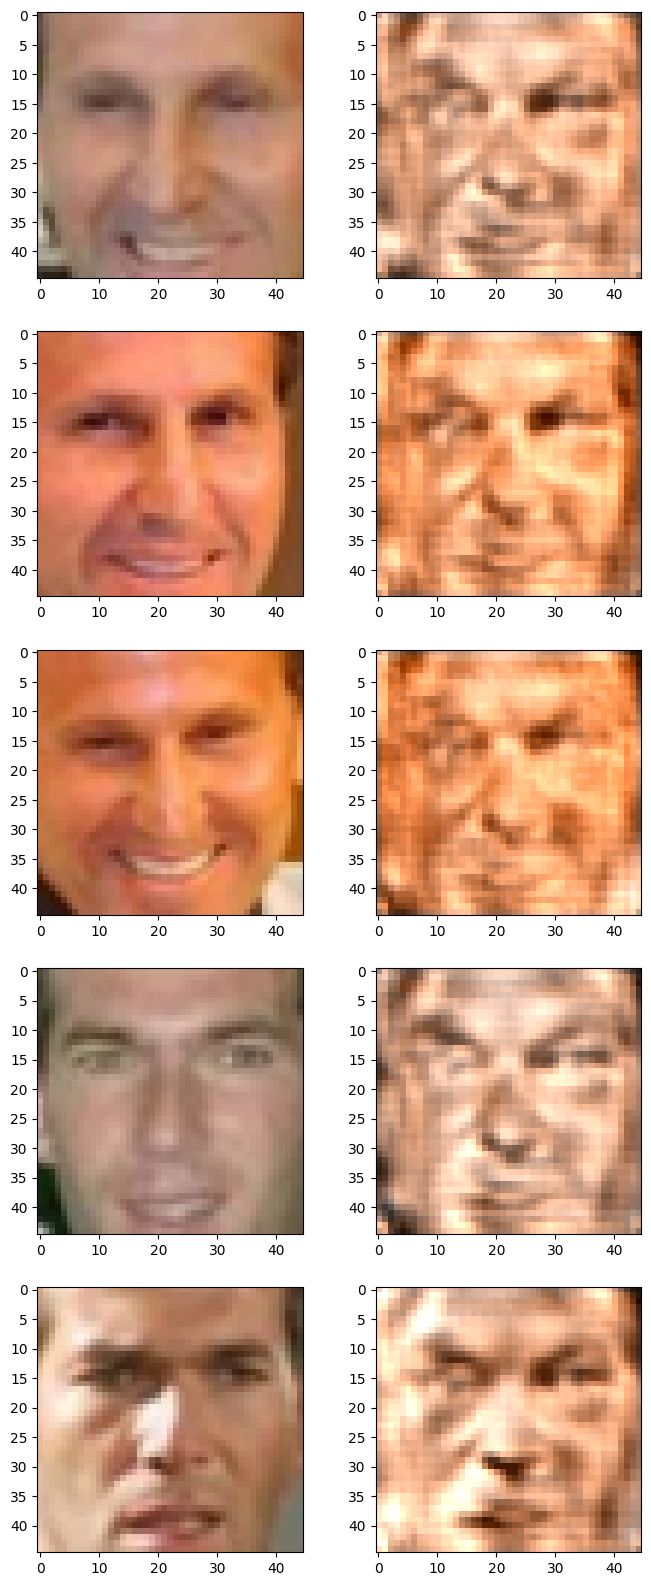

In [ ]:
model.eval()
with torch.no_grad():
  for X_batch in test_loader:
    X_batch = X_batch.permute(0,3,1,2)
    reconstruction, latent = model(X_batch.to(device))
    result = reconstruction.permute(0,2,3,1).contiguous().cpu().numpy() / 255.0
    ground_truth = X_batch.permute(0,2,3,1).contiguous().cpu().numpy() / 255.0
    ground_truth = np.clip(ground_truth, 0, 1)
    result = np.clip(result, 0, 1)
plt.figure(figsize=(8, 20))
for i, (gt, res) in enumerate(zip(ground_truth[:5], result[:5])):
  plt.subplot(5, 2, 2*i+1)
  plt.imshow(gt)
  plt.subplot(5, 2, 2*i+2)
  plt.imshow(res)


Создадим вектор улыбки, чтобы добавлять ее людям на фото. Усредним вектор улыбающихся и грустных людей, и посчитаем разность, будем добавлять ее грустным

In [ ]:
attrs['Smiling'] = attrs['Smiling'].astype(float)

In [ ]:
attrs[attrs['Smiling'] >= 1.5].head(2)

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
26,1.898225,1.083393,-1.228515,-1.416314,-2.757574,-1.101172,-0.470595,-0.218677,-0.806491,-1.41484,...,-0.851258,-0.042062,0.769485,-1.109986,1.392389,0.856509,1.973012,-1.037368,0.694004,-0.928776
88,-0.975435,-0.746867,0.658828,-2.613938,-1.352,-2.053944,0.593879,-0.43186,-1.981534,0.077876,...,0.584507,-1.664275,0.844532,1.033722,-1.133336,0.875383,1.873177,0.130292,-0.534467,0.670804


In [ ]:
attrs['Smiling'].describe()

,Smiling
count,13143.000000
mean,-0.150700
std,1.127722
min,-2.686594
25%,-1.065725
50%,-0.320783
75%,0.766401
max,2.839994


In [ ]:
attrs[attrs['Smiling'] <= -2.3].head(20)

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
49,1.29374,-0.243852,-0.850693,-0.904234,-1.735175,-0.314889,-0.782324,-0.190865,-0.685499,0.516741,...,-2.644523,0.605526,-0.964649,-1.936775,-2.150922,-1.273342,1.458763,-0.95611,1.273787,-1.385585
471,1.209976,-1.790199,0.688839,-1.638532,-1.699408,0.436127,-0.317447,-0.473203,-1.669333,-0.499657,...,0.217472,-0.728136,-1.696444,-1.401669,-3.191475,-2.248883,0.525155,-1.06538,-0.596269,-1.080036
508,-0.388401,-1.719753,-0.040092,-3.006379,-0.319824,-0.137616,-0.735406,-0.981275,-1.149148,-0.135051,...,3.239571,-0.957177,-1.337469,-0.611631,-4.057636,-1.126722,-1.201119,-0.327739,-0.098274,-0.152462
750,1.282944,-0.872623,0.998611,-1.622735,-1.602129,-0.96985,-0.82255,-0.420398,-0.455251,-1.089262,...,1.914441,0.351582,-0.309435,-1.790923,-4.00458,-0.824703,1.057019,-1.364039,0.376754,-0.742809
1234,0.954913,-0.983356,2.066999,-2.49582,-1.528766,-0.510492,-1.028936,-0.17107,-1.04501,-1.00008,...,-0.337012,0.729144,-1.764259,-1.493861,0.922482,-1.472648,-1.25914,-0.776729,-0.104821,-1.229192
1432,1.370121,-2.645392,2.89034,-2.376074,-2.172999,-1.660236,-0.755473,0.134192,-1.059732,-0.761769,...,-0.308652,1.106074,-0.919482,-1.551556,-0.838313,-1.952234,-1.570512,-0.428118,0.251507,-0.85552
1463,1.449374,-2.013694,1.728423,-2.365081,-0.633888,-0.604934,-0.862921,-0.208595,-1.264003,-0.793894,...,-0.066732,1.006319,-0.937794,-1.669203,-2.085822,-1.551783,0.752725,-0.748697,0.254012,-0.945856
1654,2.825835,-1.892106,1.253787,-1.632319,-1.885453,-0.667522,-1.40402,0.125236,-0.302133,-1.605723,...,-0.961814,1.125557,-0.898104,-1.921876,-0.933705,-1.57267,-1.594939,-1.395657,0.269789,-0.836642
1840,2.109908,-0.863335,-0.280602,-2.125765,-1.862413,-1.54873,-1.255359,-0.110789,-0.316808,0.560118,...,-0.25872,0.143422,-0.621568,-1.459625,-3.220721,-0.887871,0.254472,-0.966586,0.874735,-1.098545
1964,2.401085,-0.978042,0.654727,-1.242637,-1.550734,-1.023396,-0.965456,-0.130242,-0.157761,-1.040007,...,-0.054269,0.800541,-0.676677,-2.051262,-2.109874,-1.515886,0.718657,-1.273824,1.363406,-1.735734


array([[[247, 221, 196],
        [242, 217, 195],
        [203, 179, 165],
        ...,
        [184, 118,  86],
        [158,  99,  73],
        [127,  77,  59]],

       [[247, 221, 196],
        [241, 216, 194],
        [203, 180, 165],
        ...,
        [187, 120,  88],
        [161, 101,  74],
        [131,  80,  61]],

       [[245, 219, 194],
        [240, 215, 193],
        [208, 185, 168],
        ...,
        [192, 126,  92],
        [165, 104,  77],
        [136,  83,  63]],

       ...,

       [[ 57,  38,  31],
        [ 56,  37,  31],
        [ 53,  34,  30],
        ...,
        [130,  75,  54],
        [117,  64,  48],
        [104,  54,  41]],

       [[ 54,  35,  33],
        [ 53,  34,  32],
        [ 51,  33,  31],
        ...,
        [117,  66,  50],
        [103,  52,  41],
        [ 93,  45,  35]],

       [[ 53,  34,  37],
        [ 50,  32,  33],
        [ 47,  30,  31],
        ...,
        [109,  61,  49],
        [ 95,  46,  38],
        [ 87,  38,  30]]], dtype=uint8)
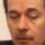

In [ ]:
images[49]

In [ ]:
numb_smile = [26,88,106,108,135,136,137,138,146,158,159,219,220,237,253]

In [ ]:
numb_sad = [471, 508, 750, 1234, 1432, 1463, 1654, 1840, 1964, 2000, 2390, 2529, 2647, 3536, 3798]

In [ ]:
X_batch = []
smile_latent = []
for i in numb_smile:
  X_batch.append(images[i])
X_batch = torch.FloatTensor(X_batch)
X_batch = X_batch.permute(0,3,1,2)
with torch.no_grad():
    _, z = model(X_batch.to(device))
mean_smile = z.mean(dim=0, keepdim=True)

In [ ]:
mean_smile

tensor([[[[2.1861, 2.1890, 2.1598,  ..., 2.0963, 2.1323, 2.1610],
          [2.2007, 2.1909, 2.1171,  ..., 2.0934, 2.0856, 2.0737],
          [2.2245, 2.1831, 2.1203,  ..., 2.1112, 2.1073, 2.0957],
          ...,
          [1.6803, 1.7776, 1.8991,  ..., 1.9929, 2.0249, 2.0043],
          [1.6873, 1.7825, 1.8746,  ..., 2.0250, 2.0302, 2.0033],
          [1.6670, 1.7778, 1.8539,  ..., 2.0483, 2.0263, 2.0145]],

         [[0.2681, 0.1736, 0.1375,  ..., 0.2559, 0.2988, 0.3247],
          [0.2556, 0.1640, 0.1162,  ..., 0.2696, 0.2931, 0.3077],
          [0.2625, 0.1658, 0.1099,  ..., 0.2828, 0.3090, 0.3113],
          ...,
          [0.1359, 0.1217, 0.1317,  ..., 0.0873, 0.0755, 0.1285],
          [0.1336, 0.1296, 0.1259,  ..., 0.1046, 0.0980, 0.1343],
          [0.1360, 0.1353, 0.1224,  ..., 0.1136, 0.1137, 0.1494]],

         [[0.0307, 0.0717, 0.1540,  ..., 0.1160, 0.0779, 0.0488],
          [0.0357, 0.1011, 0.1901,  ..., 0.1712, 0.1521, 0.1226],
          [0.0493, 0.1190, 0.1885,  ..., 0

In [ ]:
X_batch = []
for i in numb_sad:
  X_batch.append(images[i])
X_batch = torch.FloatTensor(X_batch)
X_batch = X_batch.permute(0,3,1,2)
with torch.no_grad():
    _, z = model(X_batch.to(device))
mean_sad = z.mean(dim=0, keepdim=True)

In [ ]:
X_batch = []
X_batch.append(images[3935])
X_batch = torch.FloatTensor(X_batch)
with torch.no_grad():
  X_batch = X_batch.permute(0,3,1,2)
  reconstruction, latent = model(X_batch.to(device))
  my_lat = latent

array([[[ 59,  59,  35],
        [ 96,  89,  57],
        [112,  98,  61],
        ...,
        [101,  71,  48],
        [ 89,  67,  44],
        [ 71,  59,  37]],

       [[ 42,  43,  20],
        [ 91,  84,  54],
        [111,  97,  59],
        ...,
        [104,  74,  51],
        [105,  83,  57],
        [ 76,  61,  38]],

       [[ 48,  48,  29],
        [ 98,  90,  63],
        [115, 100,  64],
        ...,
        [ 95,  69,  44],
        [101,  80,  52],
        [ 91,  78,  50]],

       ...,

       [[ 42,  40,  29],
        [ 51,  48,  38],
        [ 48,  46,  34],
        ...,
        [ 61,  56,  60],
        [ 11,   8,  13],
        [  5,   3,   6]],

       [[ 51,  49,  34],
        [ 51,  49,  35],
        [ 51,  49,  36],
        ...,
        [ 14,   9,  13],
        [  2,   0,   3],
        [  5,   3,   6]],

       [[ 52,  51,  34],
        [ 51,  50,  32],
        [ 49,  47,  32],
        ...,
        [  3,   0,   0],
        [  3,   1,   3],
        [  3,   1,   2]]], dtype=uint8)
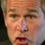

In [ ]:
images[3935]

In [ ]:
x = autoencoder.sample(latent)[0]
print(x.shape)

torch.Size([45, 45, 3])


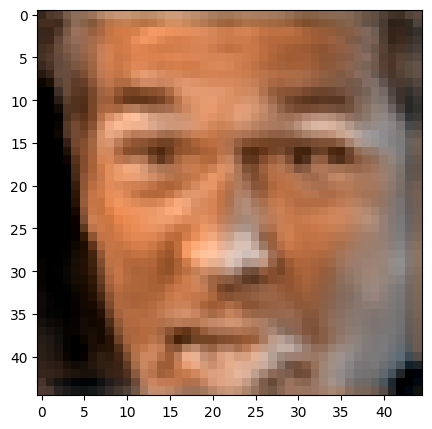

In [ ]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 1, 1)
autoencoder = autoencoder.to(device)
latent = my_lat.to(device)
model.eval()
with torch.no_grad():
  new_lat = latent + (mean_smile - mean_sad)
  img = model.sample(new_lat)[0].permute(1,2,0).contiguous().cpu().numpy() / 255
  img = np.clip(img, 0, 1)
plt.imshow(img)